In [1]:
import torch
import torch.nn as nn
import torch.functional as F
from dataclasses import dataclass


In [2]:
device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = 'mps'
print(device)

cuda


In [3]:
# hyperparams
@dataclass
class autoencConfig:
    bottleneck: int = 8

In [95]:
class AutoEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.encode = nn.Sequential(
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Linear(32, 16),
                nn.ReLU(),
                nn.Linear(16, 8),
                nn.ReLU()
        )
        
        self.bottleneck = nn.Linear(8, config.bottleneck)
        
        self.decode = nn.Sequential(
            nn.ReLU(),
            nn.Linear(config.bottleneck, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64)
        )
        
        self.ln = nn.LayerNorm(64)
        
        
    def forward(self, x, targets=None):
        x = self.encode(x)
        x = self.bottleneck(x)
        x = self.decode(x)
        
        if targets is None:
            loss = None
        else:
            x = torch.sigmoid(self.ln(x))
            loss = nn.MSELoss()(x, targets)
        return x, loss

In [ ]:
from PIL import Image
import numpy as np

img = Image.open("test.png").convert("L")
arr = np.array(img, dtype=np.float32) / 255.0  # Normalize to [0, 1]

tensor = torch.from_numpy(arr).reshape(1, 64)

print(tensor.shape)  # torch.Size([1, 64])

torch.Size([1, 64])


In [125]:
model = AutoEncoder(autoencConfig())
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

0.29356443881988525


(np.float64(-0.5), np.float64(7.5), np.float64(7.5), np.float64(-0.5))

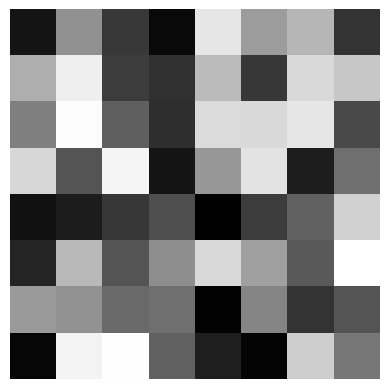

In [ ]:
for _ in range(10):
    Xb = tensor.to(device=device)
    output, loss = model(Xb, Xb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    
print(loss.item())

import matplotlib.pyplot as plt

arr = output.detach().reshape(8, 8).numpy()

img = Image.fromarray((arr * 255).clip(0, 255).astype(np.uint8), mode="L")
img.save("reconstructed.png")

plt.imshow(arr, cmap="gray")
plt.axis("off")